# VisXAI: Tree / Tabular Path Demo

This notebook walks through VisXAI's fully-working **tree/tabular**
pipeline: Morgan fingerprints &rarr; a scikit-learn model &rarr; TreeSHAP
&rarr; a colored 2D structure. See the README for an overview of the pipeline.

**Note up front:** this path produces **atom *and* bond-level attribution**
&mdash; a fingerprint bit represents a whole substructure (atoms *and* the
bonds connecting them), so `TreeSHAPExplainer` distributes each bit's SHAP
score to both, controlled by a `bond_score_mode` flag (`"duplicate"`,
the default, or `"split"`; see below).

In [1]:
from IPython.display import SVG, display
from sklearn.ensemble import RandomForestClassifier

from visxai.explainers.tree_shap import TreeSHAPExplainer
from visxai.features.fingerprints import (
    generate_maccs_representation,
    generate_morgan_representation,
)
from visxai.models.sklearn_wrapper import SklearnModelWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

## The dataset

A tiny, fully synthetic 5-molecule dataset (kept deliberately small so the demo stays fast and deterministic):

| SMILES | Molecule | Label |
|---|---|---|
| `CCO` | ethanol | 0 |
| `c1ccccc1` | benzene | 1 |
| `CC(=O)O` | acetic acid | 0 |
| `CN1CCCC1` | pyrrolidine | 1 |
| `CC(=O)Oc1ccccc1C(=O)O` | aspirin | 1 |

The labels are arbitrary (this is a toy dataset, not a real
structure-activity dataset) but give the classifier *some* structure to
key off so the resulting SHAP explanation isn't degenerate.

In [2]:
_SMILES = [
    "CCO",
    "c1ccccc1",
    "CC(=O)O",
    "CN1CCCC1",
    "CC(=O)Oc1ccccc1C(=O)O",
]
_LABELS = [0, 1, 0, 1, 1]
_N_BITS = 2048

fingerprint_matrix = [
    generate_morgan_representation(smi, n_bits=_N_BITS).fingerprint_array
    for smi in _SMILES
]

clf = RandomForestClassifier(n_estimators=10, random_state=42)
clf.fit(fingerprint_matrix, _LABELS)
print("Trained RandomForestClassifier on", len(_SMILES), "molecules.")

Trained RandomForestClassifier on 5 molecules.


[20:23:19] DEPRECATION WARNING: please use MorganGenerator
[20:23:19] DEPRECATION WARNING: please use MorganGenerator
[20:23:19] DEPRECATION WARNING: please use MorganGenerator
[20:23:19] DEPRECATION WARNING: please use MorganGenerator
[20:23:19] DEPRECATION WARNING: please use MorganGenerator


## Explaining aspirin

Aspirin (`CC(=O)Oc1ccccc1C(=O)O`) is the largest molecule in the dataset
(13 heavy atoms) and the most visually interesting to explain.

[20:23:19] DEPRECATION WARNING: please use MorganGenerator


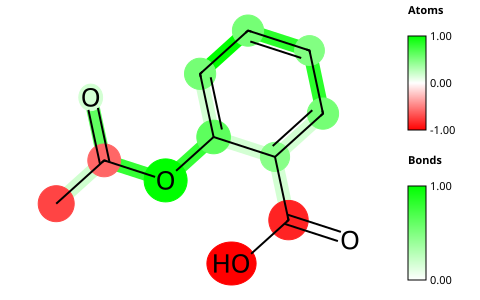

In [3]:
mol_rep = generate_morgan_representation("CC(=O)Oc1ccccc1C(=O)O", n_bits=_N_BITS)
wrapper = SklearnModelWrapper(clf)
explanation = TreeSHAPExplainer().explain(wrapper, mol_rep)

svg = RDKitSVGVisualizer().visualize(mol_rep, explanation)
display(SVG(svg))

Atoms **and bonds** are colored on a **red (negative) &ndash; white (zero) &ndash;
green (positive)** gradient, showing each element's cumulative SHAP
contribution to the prediction &mdash; bonds get a score too now, since a
fingerprint bit represents a whole substructure (atoms *and* the bonds
connecting them), not just a set of atoms. `explanation.metadata` carries
the SHAP base value and the model's raw prediction:

In [4]:
print("base_value:     ", explanation.metadata["base_value"])
print("predicted_value: ", explanation.metadata["predicted_value"])
print("n bond_scores:   ", len(explanation.bond_scores), "entries (one per bond)")

base_value:      0.6000000000000001
predicted_value:  1.0
n bond_scores:    13 entries (one per bond)


### The bit &rarr; atom/bond mapping, concretely

Every active fingerprint bit corresponds to one or more circular
environments, recorded in `mol_rep.bit_info` (atom indices) and
`mol_rep.bit_bond_info` (bond indices). For Morgan, the bond indices come
straight from RDKit's own internal environment traversal rather than
being recomputed; for MACCS, they're derived by mapping each SMARTS
pattern's bonds through its substructure matches. `TreeSHAPExplainer`
takes each bit's SHAP value and, by default (`bond_score_mode="duplicate"`),
distributes it independently across both the atoms and the bonds in that
environment (`distribute_bit_score`), then sums contributions per
atom/bond. Here's one active bit's underlying atom *and* bond
environments, next to its final per-atom and per-bond score
contributions:

In [5]:
import numpy as np

active_bits = np.flatnonzero(mol_rep.fingerprint_array)
example_bit = next(b for b in active_bits if mol_rep.bit_bond_info.get(b))
print(f"bit {example_bit} -> atom environments: {mol_rep.bit_info[example_bit]}")
print(f"bit {example_bit} -> bond environments: {mol_rep.bit_bond_info[example_bit]}")

print()
print("Full atom_scores, sorted by magnitude:")
for atom_idx, score in sorted(
    explanation.atom_scores.items(), key=lambda kv: -abs(kv[1])
):
    print(f"  atom {atom_idx}: {score:+.4f}")

print()
print("Full bond_scores, sorted by magnitude:")
for bond_idx, score in sorted(
    explanation.bond_scores.items(), key=lambda kv: -abs(kv[1])
):
    print(f"  bond {bond_idx}: {score:+.4f}")

bit 389 -> atom environments: [(10, 12)]
bit 389 -> bond environments: [(11,)]

Full atom_scores, sorted by magnitude:
  atom 3: +0.0727
  atom 4: +0.0461
  atom 5: +0.0392
  atom 6: +0.0392
  atom 8: +0.0392
  atom 7: +0.0354
  atom 9: +0.0338
  atom 12: -0.0267
  atom 10: -0.0229
  atom 0: -0.0195
  atom 1: -0.0160
  atom 2: +0.0123
  atom 11: +0.0000

Full bond_scores, sorted by magnitude:
  bond 5: +0.0248
  bond 6: +0.0206
  bond 7: +0.0206
  bond 2: +0.0197
  bond 3: +0.0197
  bond 1: +0.0154
  bond 0: +0.0046
  bond 9: +0.0043
  bond 4: +0.0043
  bond 8: +0.0043
  bond 12: +0.0043
  bond 11: +0.0000
  bond 10: +0.0000


### `bond_score_mode`: duplicate vs. split

`TreeSHAPExplainer` accepts a `bond_score_mode` flag controlling how a
bit's SHAP score relates to its bond scores:

- `"duplicate"` (the default, used above) &mdash; each bit's *full* SHAP
  score is distributed independently to both its atoms and its bonds. A
  bond in a small environment often ends up with a score equal to its
  endpoint atoms'. `atom_scores` is completely unaffected by whether bond
  attribution is enabled at all.
- `"split"` &mdash; each bit's SHAP score is divided across the
  *combined* set of its unique atoms and bonds, so `atom_scores` values
  shrink to make room for `bond_scores`: `sum(atom_scores) +
  sum(bond_scores)` for a bit's contribution equals the bit's own SHAP
  score, mirroring the graph path's Integrated-Gradients-style
  completeness axiom (see `graph_demo.ipynb`) for a more direct
  side-by-side comparison.

Same molecule, same model, both modes. The numbers below show the
difference; the interactive section at the end of this notebook puts
the two renders side by side on a shared color scale, and its readout
reports how far each bit's score was divided in each mode.

In [6]:
split_explanation = TreeSHAPExplainer(bond_score_mode="split").explain(wrapper, mol_rep)

print("duplicate mode (default):")
print(f"  sum(atom_scores) = {sum(explanation.atom_scores.values()):+.4f}")
print(f"  sum(bond_scores) = {sum(explanation.bond_scores.values()):+.4f}")

print()
print("split mode:")
print(f"  sum(atom_scores) = {sum(split_explanation.atom_scores.values()):+.4f}")
print(f"  sum(bond_scores) = {sum(split_explanation.bond_scores.values()):+.4f}")


duplicate mode (default):
  sum(atom_scores) = +0.2328
  sum(bond_scores) = +0.1425

split mode:
  sum(atom_scores) = +0.1686
  sum(bond_scores) = +0.0642


### `bond_score_mode`, concretely: one bit's contribution

The whole-molecule sums above show the two modes differ, but each sum
mixes contributions from every active bit, which obscures *why* they
differ. Isolating one specific bit makes the arithmetic exact: temporarily
restrict `bit_info`/`bit_bond_info` to just that one bit
(`dataclasses.replace`, no library changes needed) so every *other*
active bit is silently skipped as "no mapping" — the same graceful
behavior a MACCS `'?'` key gets — leaving only this bit's own contribution
in the result. Bit 1088 is used here instead of the bit from the mapping
walkthrough above, since that one happens to carry a SHAP score of
exactly `0.0` for this particular model — not a useful example for
seeing the two modes actually differ.

In [7]:
import dataclasses

mode_example_bit = 1088  # nonzero SHAP score, small clean atom+bond environment
isolated_rep = dataclasses.replace(
    mol_rep,
    bit_info={mode_example_bit: mol_rep.bit_info[mode_example_bit]},
    bit_bond_info={mode_example_bit: mol_rep.bit_bond_info[mode_example_bit]},
)
atom_ids = sorted(set().union(*mol_rep.bit_info[mode_example_bit]))
bond_ids = sorted(set().union(*mol_rep.bit_bond_info[mode_example_bit]))

isolated_dup = TreeSHAPExplainer(bond_score_mode="duplicate").explain(wrapper, isolated_rep)
isolated_split = TreeSHAPExplainer(bond_score_mode="split").explain(wrapper, isolated_rep)

print(f"bit {mode_example_bit} in isolation: {len(atom_ids)} atom(s) {atom_ids}, {len(bond_ids)} bond(s) {bond_ids}")
print()
print("duplicate mode -- full score to atoms, full score to bonds, independently:")
for a in atom_ids:
    print(f"  atom {a}: {isolated_dup.atom_scores[a]:+.4f}")
for b in bond_ids:
    print(f"  bond {b}: {isolated_dup.bond_scores[b]:+.4f}")
print(f"  (atoms sum + bonds sum = "
      f"{sum(isolated_dup.atom_scores[a] for a in atom_ids) + sum(isolated_dup.bond_scores[b] for b in bond_ids):+.4f}"
      f" -- double-counts the bit's score, not a completeness total)")

print()
print("split mode -- score divided across the combined atom+bond count:")
for a in atom_ids:
    print(f"  atom {a}: {isolated_split.atom_scores[a]:+.4f}")
for b in bond_ids:
    print(f"  bond {b}: {isolated_split.bond_scores[b]:+.4f}")
print(f"  (atoms sum + bonds sum = "
      f"{sum(isolated_split.atom_scores[a] for a in atom_ids) + sum(isolated_split.bond_scores[b] for b in bond_ids):+.4f}"
      f" -- equals the bit's own SHAP score, a real completeness total)")

bit 1088 in isolation: 4 atom(s) [5, 6, 7, 8], 3 bond(s) [5, 6, 7]

duplicate mode -- full score to atoms, full score to bonds, independently:
  atom 5: +0.0154
  atom 6: +0.0154
  atom 7: +0.0154
  atom 8: +0.0154
  bond 5: +0.0206
  bond 6: +0.0206
  bond 7: +0.0206
  (atoms sum + bonds sum = +0.1233 -- double-counts the bit's score, not a completeness total)

split mode -- score divided across the combined atom+bond count:
  atom 5: +0.0088
  atom 6: +0.0088
  atom 7: +0.0088
  atom 8: +0.0088
  bond 5: +0.0088
  bond 6: +0.0088
  bond 7: +0.0088
  (atoms sum + bonds sum = +0.0617 -- equals the bit's own SHAP score, a real completeness total)


## A second molecule, for contrast

Benzene is a deliberately tricky second example, not a straightforward
one: `TreeSHAPExplainer` gives all six aromatic carbons **exactly** the
same score, so the render below is a solid white molecule rather than a
red/green gradient. This isn't a rendering bug &mdash; benzene's D6h
symmetry means every carbon sits in an identical fingerprint environment,
so TreeSHAP's per-bit scores land on every atom equally. `RDKitSVGVisualizer`
has a documented degenerate case for exactly this
(`min_score == max_score` &rarr; solid white, legend prints `0.00`) so it
doesn't divide by zero &mdash; but note the `0.00` on the legend describes
the *normalized* value, not the raw score, which is printed below and is
not actually zero:

Raw atom_scores (all identical, not zero): {0: 0.03356481481481481, 1: 0.03356481481481481, 2: 0.03356481481481481, 3: 0.03356481481481481, 4: 0.03356481481481481, 5: 0.03356481481481481}
Raw bond_scores (all identical, not zero): {0: 0.013981481481481484, 1: 0.013981481481481484, 2: 0.013981481481481484, 3: 0.013981481481481484, 4: 0.013981481481481484, 5: 0.013981481481481484}


[20:23:19] DEPRECATION WARNING: please use MorganGenerator


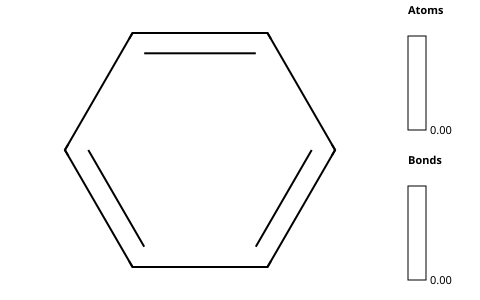

In [8]:
benzene_rep = generate_morgan_representation("c1ccccc1", n_bits=_N_BITS)
benzene_explanation = TreeSHAPExplainer().explain(wrapper, benzene_rep)

print("Raw atom_scores (all identical, not zero):", benzene_explanation.atom_scores)
print("Raw bond_scores (all identical, not zero):", benzene_explanation.bond_scores)

display(SVG(RDKitSVGVisualizer().visualize(benzene_rep, benzene_explanation)))

For the actual contrast this section originally promised &mdash; visibly
different colors from atom to atom &mdash; ethanol works better than
benzene precisely because it *isn't* symmetric. Its scores are printed
below, and it is one of the molecules selectable in the interactive
section at the end:

In [9]:
ethanol_rep = generate_morgan_representation("CCO", n_bits=_N_BITS)
ethanol_explanation = TreeSHAPExplainer().explain(wrapper, ethanol_rep)

print("Raw atom_scores:", ethanol_explanation.atom_scores)


Raw atom_scores: {1: -0.028055555555555556, 2: -0.13305555555555554, 0: -0.011111111111111113}


[20:23:19] DEPRECATION WARNING: please use MorganGenerator


## MACCS keys, for contrast with Morgan fingerprints

Everything above used **Morgan fingerprints** — hashed circular
substructures, with a configurable `n_bits` (`2048` here). **MACCS
keys** are the tree path's other supported scheme
(`generate_maccs_representation`): 166 *predefined* structural keys (a
fixed-length, human-interpretable vocabulary — e.g. "has a ring of size
6", "has a nitro group" — rather than arbitrary hashed bits), with no
`n_bits` parameter since the key set itself is fixed. Bit semantics are
completely different from Morgan's, so this needs its own freshly-trained
model — `clf` above can't be reused, the same way you wouldn't reuse a
model trained on one feature scheme to score another's features.

In [10]:
maccs_fingerprint_matrix = [
    generate_maccs_representation(smi).fingerprint_array for smi in _SMILES
]

maccs_clf = RandomForestClassifier(n_estimators=10, random_state=42)
maccs_clf.fit(maccs_fingerprint_matrix, _LABELS)
print("Trained RandomForestClassifier on", len(_SMILES), "molecules (MACCS keys).")

Trained RandomForestClassifier on 5 molecules (MACCS keys).


### Explaining aspirin with MACCS keys

Same molecule, same `TreeSHAPExplainer`/`RDKitSVGVisualizer` pipeline —
only the fingerprint scheme (and the model trained on it) changed.
`bit_bond_info` for MACCS is derived differently than Morgan's (mapping
each active key's own SMARTS pattern through its substructure matches,
rather than reusing RDKit's environment traversal — see the "bit →
atom/bond mapping" cell above), but that's invisible from the caller's
side: bond-level attribution still works the same way.

This explanation is registered in the interactive dashboard at the end
of the notebook as `aspirin (MACCS)`, so it can be compared directly
against the Morgan explanations of the same molecule.

In [11]:
maccs_mol_rep = generate_maccs_representation("CC(=O)Oc1ccccc1C(=O)O")
maccs_wrapper = SklearnModelWrapper(maccs_clf)
maccs_explanation = TreeSHAPExplainer().explain(maccs_wrapper, maccs_mol_rep)

print("MACCS active keys explained:", len(maccs_explanation.atom_provenance), "atoms with provenance")
print(f"atoms scored: {len(maccs_explanation.atom_scores)} / {maccs_mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(maccs_explanation.bond_scores)} / {maccs_mol_rep.mol.GetNumBonds()}")

MACCS active keys explained: 13 atoms with provenance
atoms scored: 13 / 13
bonds scored: 13 / 13


In [12]:
print("base_value:      ", maccs_explanation.metadata["base_value"])
print("predicted_value: ", maccs_explanation.metadata["predicted_value"])
print("n bond_scores:   ", len(maccs_explanation.bond_scores), "entries (one per bond)")
print()
print("active Morgan bits (n_bits=2048):", int(mol_rep.fingerprint_array.sum()))
print("active MACCS keys  (of 166):     ", int(maccs_mol_rep.fingerprint_array.sum()))

base_value:       0.6000000000000001
predicted_value:  1.0
n bond_scores:    13 entries (one per bond)

active Morgan bits (n_bits=2048): 24
active MACCS keys  (of 166):      21


### Morgan vs. MACCS, compared directly

The two schemes trained two *different models*, so their SHAP values are not
on a common footing: each is measured against its own `base_value`, over its
own feature space, and no bit index means the same thing in both. Comparing
the raw magnitudes atom-by-atom would be a category error.

What *is* comparable is **where each scheme puts the signal** — the ranking of
atoms — and **how each one gets there**, which is exactly what
`atom_provenance` records.

In [13]:
n_atoms = mol_rep.mol.GetNumAtoms()
morgan_v = [explanation.atom_scores[i] for i in range(n_atoms)]
maccs_v = [maccs_explanation.atom_scores[i] for i in range(n_atoms)]

print(f"{'atom':>4} {'sym':>4} {'Morgan':>10} {'MACCS':>10}  sign")
for idx in range(n_atoms):
    m, k = morgan_v[idx], maccs_v[idx]
    if m == 0.0 or k == 0.0:
        agreement = "  --"          # one side has nothing to agree with
    else:
        agreement = "  ok" if (m > 0) == (k > 0) else "  NO"
    print(f"{idx:>4} {mol_rep.mol.GetAtomWithIdx(idx).GetSymbol():>4} "
          f"{m:>+10.4f} {k:>+10.4f} {agreement}")


def average_ranks(values):
    """Ranks with ties averaged. Spearman's rho is Pearson's r on these."""
    order = sorted(range(len(values)), key=lambda i: values[i])
    ranks = [0.0] * len(values)
    start = 0
    while start < len(order):
        stop = start
        while stop + 1 < len(order) and values[order[stop + 1]] == values[order[start]]:
            stop += 1
        for position in range(start, stop + 1):
            ranks[order[position]] = (start + stop) / 2.0
        start = stop + 1
    return ranks


rho = float(np.corrcoef(average_ranks(morgan_v), average_ranks(maccs_v))[0, 1])
print(f"\nSpearman rank correlation: {rho:+.3f}")

top4 = lambda values: sorted(range(n_atoms), key=lambda i: -values[i])[:4]
print("top-4 atoms  Morgan:", top4(morgan_v), " MACCS:", top4(maccs_v))
print("      shared by both:", sorted(set(top4(morgan_v)) & set(top4(maccs_v))))

atom  sym     Morgan      MACCS  sign
   0    C    -0.0195    +0.0000   --
   1    C    -0.0160    -0.0189   ok
   2    O    +0.0123    -0.0420   NO
   3    O    +0.0727    +0.0272   ok
   4    C    +0.0461    +0.0657   ok
   5    C    +0.0392    +0.0511   ok
   6    C    +0.0392    +0.0077   ok
   7    C    +0.0354    +0.0077   ok
   8    C    +0.0392    +0.0077   ok
   9    C    +0.0338    +0.0711   ok
  10    C    -0.0229    +0.0011   NO
  11    O    +0.0000    -0.0353   --
  12    O    -0.0267    -0.0295   ok

Spearman rank correlation: +0.689
top-4 atoms  Morgan: [3, 4, 5, 6]  MACCS: [9, 4, 5, 3]
      shared by both: [3, 4, 5]


Three things in that table are worth naming.

**The rankings broadly agree; the fringes don't.** A rank correlation near
0.7, with three of the top four atoms shared, is real agreement about the
ester oxygen and the aromatic ring — reached through two bit vocabularies
with no index in common. The sign flips all sit on atoms an order of
magnitude smaller: a near-zero score is the *absence* of a claim, not a claim
of neutrality, and two schemes can be absent in different directions.

**A zero means two different things**, and only the itemisation tells them
apart — no source touched this atom at all, versus sources touched it and
every one of them scored zero. Same rendered color, entirely different
statement about the model.

**A source is only as readable as its scheme allows.** A MACCS key carries a
published SMARTS definition that holds for every molecule. A Morgan bit is a
hash: VisXAI can report which environments it matched *in this molecule*, and
that is genuinely all there is to say about it. This is the interpretability
half of the tradeoff — the reason the choice between schemes isn't only about
accuracy.

`graph_demo.ipynb` runs this same test on the graph path, swapping the
*featurizer* rather than the fingerprint scheme, and gets a notably different
answer about how much the ranking survives the change.

In [14]:
from rdkit.Chem import MACCSkeys

# Where the two schemes disagree about zero -- and which kind of zero it is.
for idx in range(n_atoms):
    m, k = morgan_v[idx], maccs_v[idx]
    if (m == 0.0) == (k == 0.0):
        continue
    if m == 0.0:
        zeroed, exp, other_score = "Morgan", explanation, k
    else:
        zeroed, exp, other_score = "MACCS", maccs_explanation, m
    contributions = exp.atom_provenance.get(idx, [])
    informative = sum(1 for c in contributions if c["source_score"] != 0.0)
    print(f"atom {idx} ({mol_rep.mol.GetAtomWithIdx(idx).GetSymbol()}): "
          f"{zeroed} scores 0.0000, the other scheme {other_score:+.4f}")
    print(f"    {zeroed} sources covering it: {len(contributions)}, "
          f"of which nonzero: {informative}")


def top_sources(exp, k=3):
    """Highest-magnitude sources, deduplicated across the atoms they touched."""
    by_source = {}
    for contributions in exp.atom_provenance.values():
        for c in contributions:
            by_source[c["source_index"]] = c["source_score"]
    return sorted(by_source.items(), key=lambda kv: -abs(kv[1]))[:k]


print("\nMACCS -- every key has a published definition:")
for key_idx, score in top_sources(maccs_explanation):
    smarts, threshold = MACCSkeys.smartsPatts[key_idx]
    print(f"  key {key_idx:>4}  score {score:+.4f}  "
          f"SMARTS {smarts!r} (fires at >= {threshold + 1} "
          f"match{'es' if threshold else ''})")

print("\nMorgan -- a bit is a hash; its only definition is what it matched here:")
for bit_idx, score in top_sources(explanation):
    environments = mol_rep.bit_info.get(bit_idx, [])
    covered = sorted({atom for env in environments for atom in env})
    print(f"  bit {bit_idx:>4}  score {score:+.4f}  "
          f"{len(environments)} environment(s) covering atoms {covered}")

atom 0 (C): MACCS scores 0.0000, the other scheme -0.0195
    MACCS sources covering it: 1, of which nonzero: 0
atom 11 (O): Morgan scores 0.0000, the other scheme -0.0353
    Morgan sources covering it: 5, of which nonzero: 0

MACCS -- every key has a published definition:
  key  127  score +0.1200  SMARTS '*@*!@[#8]' (fires at >= 2 matches)
  key  164  score -0.0800  SMARTS '[#8]' (fires at >= 1 match)
  key  143  score +0.0533  SMARTS '*@*!@[#8]' (fires at >= 1 match)

Morgan -- a bit is a hash; its only definition is what it matched here:
  bit 1873  score +0.0800  4 environment(s) covering atoms [5, 6, 7, 8]
  bit  807  score -0.0800  3 environment(s) covering atoms [1, 10, 12]
  bit 1775  score +0.0617  1 environment(s) covering atoms [0, 1, 2, 3, 4]


## Interactive exploration

Everything above renders a **static** SVG. The same explanations can be
explored interactively instead, with no re-computation: `ExplanationDashboard`
re-renders explanations that already exist, and never re-runs an explainer.

Each panel is a `MoleculeHoverWidget` — the structure paired with an
XSMILES-style SMILES strip, cross-highlighting as the cursor moves, with a
readout giving the raw score, the normalized value driving the color, and
**how that score was assembled**.

Two things to know before running this:

- It needs a **live kernel** and the `viz` extra (`pip install -e ".[viz]"`,
  which brings `ipywidgets>=8` and `anywidget`). A rendered copy on GitHub or
  nbviewer shows a blank area where the widget would be.
- Nothing here is paradigm-specific. The dashboard only touches
  `MoleculeRepresentation` and `Explanation`, so the code below is the same in
  all three demo notebooks.

In [15]:
from visxai.visualizers.interactive import ExplanationDashboard

# {molecule: (mol_rep, {explainer_label: explanation})} -- mol_rep is written
# once per molecule, not once per explanation.
results = {
    "aspirin": (mol_rep, {
        "TreeSHAP (duplicate)": explanation,
        "TreeSHAP (split)": split_explanation,
    }),
    "benzene": (benzene_rep, {"TreeSHAP (duplicate)": benzene_explanation}),
    "ethanol": (ethanol_rep, {"TreeSHAP (duplicate)": ethanol_explanation}),
    # A different fingerprint scheme entirely -- same molecule, same
    # explainer, different bit semantics underneath.
    "aspirin (MACCS)": (maccs_mol_rep, {"TreeSHAP (duplicate)": maccs_explanation}),
}

dashboard = ExplanationDashboard.from_results(results, width=380, height=300)
print("molecules: ", dashboard.molecules)
print("explainers:", dashboard.explainers)

molecules:  ['aspirin', 'benzene', 'ethanol', 'aspirin (MACCS)']
explainers: ['TreeSHAP (duplicate)', 'TreeSHAP (split)']


### What the readout says about `duplicate` vs `split`

This is the notebook where the two `bond_score_mode` settings actually differ,
so it is worth hovering an atom in each panel and reading the last segment of
the readout.

A score is a *sum of shares* from every active bit that touched the element.
The readout reports how many bits contributed and how far each one was
divided — and that divisor is exactly where the two modes part company:

- **`"duplicate"`** divides a bit's score across its atoms, then divides the
  *same* score again across its bonds. Each side's divisor is its own count.
- **`"split"`** divides once across the atoms and bonds pooled together, so the
  divisors are larger and each element's share is smaller.

The cell below prints that directly, without needing a browser.

In [16]:
from visxai.visualizers.rdkit_2d import _format_provenance

for label, exp in (("duplicate", explanation), ("split", split_explanation)):
    divisors = sorted({
        c["shared_among"]
        for contributions in exp.atom_provenance.values()
        for c in contributions
    })
    print(f'{label:<10} attribution={exp.metadata["attribution"]:<16} '
          f'divisors {divisors[0]}-{divisors[-1]}')
    # The three atoms carrying the most signal, rather than fixed
    # indices that may well have landed on a zero score.
    top = sorted(exp.atom_scores, key=lambda i: -abs(exp.atom_scores[i]))[:3]
    for atom_idx in top:
        print(f'    atom {atom_idx:>2}: score {exp.atom_scores[atom_idx]:+.4f}'
              f'  -- {_format_provenance(exp.atom_provenance.get(atom_idx))}')

# Both modes draw on the same bits; only the sharing changes.
bits = lambda e: {c["source_index"]
                  for cl in e.atom_provenance.values() for c in cl}
print("\nsame contributing bits in both modes:",
      bits(explanation) == bits(split_explanation))

duplicate  attribution=tree/duplicate   divisors 1-9
    atom  3: score +0.0727  -- 9 bits, each split 1-9 ways
    atom  4: score +0.0461  -- 13 bits, each split 2-9 ways
    atom  5: score +0.0392  -- 9 bits, each split 4-9 ways
split      attribution=tree/split       divisors 1-17
    atom  3: score +0.0655  -- 9 bits, each split 1-17 ways
    atom  4: score +0.0389  -- 13 bits, each split 2-17 ways
    atom  9: score +0.0320  -- 12 bits, each split 2-17 ways

same contributing bits in both modes: True


In [17]:
dashboard.display()

In [18]:
# Sanity check, so this section is verifiable without a browser.
#
# nbclient executes `display(widget)` happily whether or not anything
# actually renders, so executing the notebook proves very little on its own
# (the same reason dashboard_demo.ipynb carries a cell like this). These
# asserts use only the public API -- render_svg() returns the same SVG a
# panel shows, independent of the widget tree.
import re


def strip_ids(svg):
    """RDKit gives every render a fresh random gradient id."""
    return re.sub(r'visxaiLegendGradient\w*', 'GRAD', svg)


rendered = {
    (mol, exp): dashboard.render_svg(mol, exp)
    for mol in dashboard.molecules
    for exp in dashboard.explainers
    if dashboard.render_svg(mol, exp) is not None
}
assert rendered, "no registered pair rendered"
for (mol, exp), svg in rendered.items():
    assert svg.startswith("<svg") or "<svg" in svg, (mol, exp)
    assert "<title>" in svg, f"tooltips missing for {mol}/{exp}"

print(f"rendered {len(rendered)} panel(s) across "
      f"{len(dashboard.molecules)} molecule(s) x {len(dashboard.explainers)} explainer(s)")

# The provenance clause reaches the tooltip text itself.
clauses = sorted({
    m.group(1)
    for svg in rendered.values()
    for m in re.finditer(r'<title>[^<]*\u2014 ([^<]+)</title>', svg)
})
print("provenance clauses seen:", clauses[:3] or "(none recorded)")

rendered 5 panel(s) across 4 molecule(s) x 2 explainer(s)
provenance clauses seen: ['1 bit, in full', '1 bit, split 6 ways', '10 bits, each split 4-6 ways']


## Next steps

- See `sequence_demo.ipynb` for the sequence-path pipeline, whose
  bond-level attribution is inherently *partial* (most SMILES bonds have
  no explicit character to measure) — contrast with this path's full
  bond coverage, and with `graph_demo.ipynb`'s Integrated-Gradients-based
  full atom+bond attribution.